# Vanishing Gradient Demonstration (PyTorch)
This notebook explains each step line-by-line to demonstrate the vanishing gradient problem.

## 1. Import Libraries
We import PyTorch for deep learning and Matplotlib for plotting.

In [1]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

## 2. Set Random Seed
Ensures reproducibility so results remain consistent.

In [2]:
torch.manual_seed(0)

## 3. Create Synthetic Dataset
We generate random data just to observe gradient behavior.

In [3]:
X = torch.randn(100, 10)   # 100 samples, 10 features
y = torch.randn(100, 1)

## 4. Define Deep Neural Network
We build a deep network with 20 layers using Sigmoid activation (causes vanishing gradients).

In [4]:
class DeepNN(nn.Module):
    def __init__(self):
        super(DeepNN, self).__init__()

        layers = []
        input_size = 10

        for _ in range(20):
            layers.append(nn.Linear(input_size, 10))
            layers.append(nn.Sigmoid())
            input_size = 10

        layers.append(nn.Linear(10, 1))
        self.model = nn.Sequential(*layers)

    def forward(self, x):
        return self.model(x)

## 5. Initialize Model

In [5]:
model = DeepNN()

## 6. Loss Function and Optimizer
We use Mean Squared Error and SGD optimizer.

In [6]:
criterion = nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)

## 7. Forward Pass
We pass input through the network.

In [7]:
output = model(X)
loss = criterion(output, y)

## 8. Backward Pass
This is where gradients are computed (vanishing happens here).

In [8]:
optimizer.zero_grad()
loss.backward()

## 9. Collect Gradient Values
We extract average gradient magnitude for each layer.

In [9]:
gradients = []

for name, param in model.named_parameters():
    if "weight" in name:
        gradients.append(param.grad.abs().mean().item())

## 10. Plot Gradients
We visualize how gradients shrink in earlier layers.

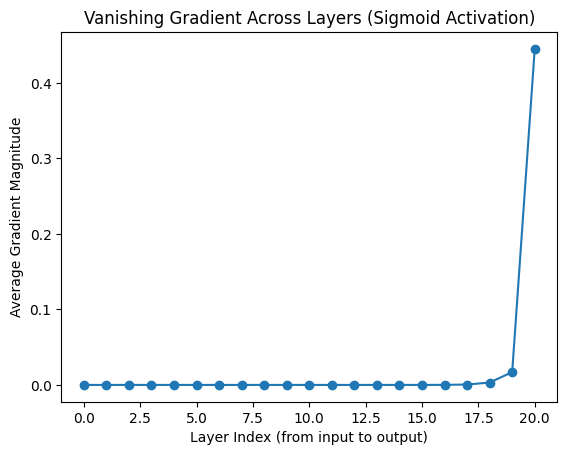

In [10]:
plt.figure()
plt.plot(gradients, marker='o')
plt.title("Vanishing Gradient Across Layers (Sigmoid Activation)")
plt.xlabel("Layer Index (from input to output)")
plt.ylabel("Average Gradient Magnitude")
plt.show()